# Part 1: Bias Detection — Comprehensive Pre-Training Audit

**vfairness.preprocessing** — Bias Detection Before Training

This notebook demonstrates the four building blocks of the bias detection module for pre-training data auditing.

The vfairness library is organized into eight parts following the ML fairness pipeline:
- **Part 1 — Data & Preprocessing** (`vfairness.preprocessing`) — Feature transforms, bias auditing
- **Part 2 — Training-Time Interventions** (`vfairness.in_processing`) — Losses, constraints, regularizers
- **Part 3 — Prediction-Time Interventions** (`vfairness.post_processing`) — Calibration, threshold tuning
- **Part 4 — Evaluation & Measurement** (`vfairness.evaluation`) — Metrics, statistics, visualization
- **Part 5 — Operations & Monitoring** (`vfairness.operations`) — MLOps, real-time monitoring, drift detection
- **Part 6 — Reporting & Dashboards** (`vfairness.operations.reporting`) — Interactive dashboards, automated reports
- **Part 7 — Experimentation** (`vfairness.operations.experimentation`) — A/B testing, Pareto & causal
- **Part 8 — Workflow Integration** (`vfairness.operations.cicd`) — CI/CD gates, pre-commit hooks, pytest plugin, report cards

> This notebook covers **Part 1** — bias detection capabilities within `vfairness.preprocessing`.

## Bias Detection Components

1. **A. Historical Pattern Detection** — Identify features linked to historical discrimination
2. **B. Representation Bias Detection** — Detect under/overrepresentation of groups
3. **C. Statistical Disparity Analysis** — Rigorous hypothesis testing for group differences
4. **D. Proxy Variable Identification** — Find features correlated with protected attributes
5. **E. Geographic Discrimination Data** — Integration with HOLC redlining maps and official databases

The module provides a unified `BiasDetector` class that combines all four capabilities into a comprehensive audit workflow.

---

## Table of Contents

1. [Setup & Data Generation](#1-setup--data-generation)
2. [A. Historical Pattern Detection](#2-a-historical-pattern-detection)
   - [Academic References & Official Data Sources](#academic-references--official-data-sources)
   - [Geographic Discrimination Data Integration](#geographic-discrimination-data-integration)
3. [B. Representation Bias Detection](#3-b-representation-bias-detection)
4. [C. Statistical Disparity Analysis](#4-c-statistical-disparity-analysis)
5. [D. Proxy Variable Identification](#5-d-proxy-variable-identification)
6. [Unified BiasDetector](#6-unified-biasdetector)
7. [Real-World Use Case: Loan Application Audit](#7-real-world-use-case-loan-application-audit)

## 1. Setup & Data Generation

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Import the bias detection module
from vfairness.preprocessing.bias_detection import (
    # Main detector class
    BiasDetector,
    BiasAuditReport,
    
    # A. Historical Pattern Detection
    detect_historical_patterns,
    HistoricalPatternResult,
    HISTORICAL_RISK_PATTERNS,
    
    # B. Representation Bias Detection
    detect_representation_bias,
    RepresentationBiasResult,
    compare_to_benchmark,
    
    # C. Statistical Disparity Analysis
    analyze_statistical_disparities,
    StatisticalDisparityResult,
    run_disparity_tests,
    compute_effect_sizes,
    
    # D. Proxy Variable Identification
    identify_proxy_variables,
    ProxyVariableResult,
    compute_proxy_correlations,
)

print("Bias Detection Module loaded successfully!")
print(f"Available historical patterns: {len(HISTORICAL_RISK_PATTERNS)}")
from vfairness.preprocessing.feature_engineering import plot_feature_correlation_matrix



Bias Detection Module loaded successfully!
Available historical patterns: 43


### Create a Synthetic Dataset with Known Biases

We'll create a dataset that simulates a **European loan/credit application scenario** with:
- **Representation bias**: Underrepresentation of minorities
- **US patterns**: ZIP codes and school names encoding historical redlining & educational discrimination
- **EU patterns**: Migration background, SCHUFA-style postcode scoring, language proficiency
- **EU AI Act triggers**: Automated credit decision, emotion-based engagement score, CV scoring
- **Swiss patterns**: Permit type (Ausweis B/C/F/N), Betreibungsauszug, Gemeinde code
- **Statistical disparities**: Different approval rates across groups
- **Proxy variables**: Features correlated with protected attributes

In [2]:
np.random.seed(42)
n_samples = 2000

# =============================================================================
# BASE DEMOGRAPHICS (with representation bias)
# =============================================================================
race_probs = [0.75, 0.10, 0.08, 0.07]  # White overrepresented
race = np.random.choice(
    ['white', 'black', 'hispanic', 'asian'], 
    n_samples, 
    p=race_probs
)

gender = np.random.choice(['male', 'female'], n_samples, p=[0.55, 0.45])
age = np.random.randint(22, 68, n_samples)

# =============================================================================
# 🇺🇸 US PATTERNS — redlining, school names, credit history
# =============================================================================

# ZIP codes correlate with race (simulating redlining)
zip_codes = []
for r in race:
    if r == 'white':
        zip_codes.append(np.random.choice(['90210', '10001', '60601'], p=[0.5, 0.3, 0.2]))
    elif r == 'black':
        zip_codes.append(np.random.choice(['30301', '48201', '21201'], p=[0.4, 0.4, 0.2]))
    elif r == 'hispanic':
        zip_codes.append(np.random.choice(['79901', '33101', '85001'], p=[0.4, 0.3, 0.3]))
    else:
        zip_codes.append(np.random.choice(['94102', '10001', '60601'], p=[0.5, 0.3, 0.2]))

# School names that encode socioeconomic status
schools = []
for r in race:
    if r == 'white':
        schools.append(np.random.choice(['Harvard', 'Stanford', 'State University', 'Community College'], 
                                        p=[0.15, 0.15, 0.50, 0.20]))
    else:
        schools.append(np.random.choice(['Harvard', 'Stanford', 'State University', 'Community College'], 
                                        p=[0.05, 0.05, 0.40, 0.50]))

# Credit score with historical bias (lower for minorities)
credit_scores = []
for r in race:
    if r == 'white':
        credit_scores.append(np.random.normal(720, 50))
    elif r == 'black':
        credit_scores.append(np.random.normal(650, 60))
    elif r == 'hispanic':
        credit_scores.append(np.random.normal(670, 55))
    else:
        credit_scores.append(np.random.normal(710, 50))
credit_scores = np.clip(credit_scores, 300, 850).astype(int)

# =============================================================================
# 🇪🇺 EU PATTERNS — migration background, postcode scoring, language
# =============================================================================

# Country of origin → triggers 'migration_background' pattern
country_of_origin = []
for r in race:
    if r == 'white':
        country_of_origin.append(np.random.choice(
            ['Switzerland', 'Germany', 'France', 'Italy', 'Austria'],
            p=[0.40, 0.25, 0.15, 0.10, 0.10]))
    elif r == 'black':
        country_of_origin.append(np.random.choice(
            ['Eritrea', 'Somalia', 'Nigeria', 'DR Congo', 'Switzerland'],
            p=[0.30, 0.25, 0.20, 0.15, 0.10]))
    elif r == 'hispanic':
        country_of_origin.append(np.random.choice(
            ['Turkey', 'Portugal', 'Spain', 'Kosovo', 'Switzerland'],
            p=[0.30, 0.25, 0.20, 0.15, 0.10]))
    else:
        country_of_origin.append(np.random.choice(
            ['Sri Lanka', 'China', 'Thailand', 'Vietnam', 'Switzerland'],
            p=[0.30, 0.25, 0.20, 0.15, 0.10]))

# Postcode score (SCHUFA-style) → triggers 'european_credit_scoring' pattern
# Biased: minorities in lower-scored postcodes
postcode_score = []
for r in race:
    if r == 'white':
        postcode_score.append(np.random.choice(['A', 'B', 'C'], p=[0.50, 0.35, 0.15]))
    else:
        postcode_score.append(np.random.choice(['A', 'B', 'C'], p=[0.15, 0.30, 0.55]))

# Language proficiency score → triggers 'language_discrimination' pattern
language_score = []
for co in country_of_origin:
    if co in ['Switzerland', 'Germany', 'Austria']:
        language_score.append(np.random.choice(['C2', 'C1', 'B2'], p=[0.60, 0.30, 0.10]))
    elif co in ['France', 'Italy', 'Portugal', 'Spain']:
        language_score.append(np.random.choice(['C1', 'B2', 'B1'], p=[0.30, 0.40, 0.30]))
    else:
        language_score.append(np.random.choice(['B2', 'B1', 'A2'], p=[0.20, 0.40, 0.40]))

# =============================================================================
# ⚖️ EU AI ACT PATTERNS — credit decisions, emotion, CV scoring
# =============================================================================

# Automated credit decision → triggers 'euaia_creditworthiness' pattern
# This simulates an AI-generated probability-of-default score
probability_of_default = []
for r, cs in zip(race, credit_scores):
    base_pd = max(0.01, 1.0 - cs / 900)
    if r in ['black', 'hispanic']:
        base_pd *= 1.3  # Biased model
    probability_of_default.append(round(min(0.99, base_pd + np.random.normal(0, 0.05)), 3))

# Engagement score (emotion-based) → triggers 'euaia_emotion_recognition' pattern
# Simulates a facial-analysis-based "engagement" metric from video interview
engagement_score = []
for g, r in zip(gender, race):
    base = np.random.normal(0.70, 0.10)
    if g == 'female':
        base -= 0.03
    if r in ['black', 'asian']:
        base -= 0.08  # Biased emotion recognition
    engagement_score.append(round(np.clip(base, 0.1, 1.0), 2))

# CV/resume score → triggers 'euaia_hr_recruitment' pattern
cv_score = []
for r, s in zip(race, schools):
    base = np.random.normal(65, 15)
    if s in ['Harvard', 'Stanford']:
        base += 15
    if r == 'white':
        base += 5  # Implicit bias in NLP scoring
    cv_score.append(int(np.clip(base, 10, 100)))

# =============================================================================
# 🇨🇭 SWISS PATTERNS — permit type, Betreibung, Gemeinde
# =============================================================================

# Swiss permit type → triggers 'swiss_permit_system' pattern
permit_type = []
for co in country_of_origin:
    if co == 'Switzerland':
        permit_type.append('Swiss citizen')
    elif co in ['Germany', 'France', 'Italy', 'Austria', 'Portugal', 'Spain']:
        permit_type.append(np.random.choice(['Ausweis C', 'Ausweis B'], p=[0.60, 0.40]))
    elif co in ['Turkey', 'Kosovo']:
        permit_type.append(np.random.choice(['Ausweis C', 'Ausweis B', 'Ausweis F'], p=[0.30, 0.50, 0.20]))
    else:
        permit_type.append(np.random.choice(['Ausweis B', 'Ausweis F', 'Ausweis N'], p=[0.30, 0.40, 0.30]))

# Betreibungsauszug entries → triggers 'swiss_betreibung' pattern
# Immigrants more likely to have entries (unfamiliarity with system)
betreibungsauszug = []
for pt in permit_type:
    if pt == 'Swiss citizen':
        betreibungsauszug.append(np.random.choice([0, 1, 2], p=[0.80, 0.15, 0.05]))
    elif pt == 'Ausweis C':
        betreibungsauszug.append(np.random.choice([0, 1, 2, 3], p=[0.60, 0.25, 0.10, 0.05]))
    else:
        betreibungsauszug.append(np.random.choice([0, 1, 2, 3, 4], p=[0.40, 0.25, 0.20, 0.10, 0.05]))

# BFS Gemeinde code → triggers 'swiss_gemeinde_data' pattern
gemeinde_code = []
for r, pt in zip(race, permit_type):
    if pt == 'Swiss citizen' and r == 'white':
        gemeinde_code.append(np.random.choice([261, 351, 1201, 2701, 6621],  # Zürich, Wollerau, Bern, Luzern, Freienbach
                                               p=[0.25, 0.20, 0.25, 0.15, 0.15]))
    else:
        gemeinde_code.append(np.random.choice([261, 230, 1201, 3203, 6266],  # Zürich, Dietikon, Bern, Biel, Emmen
                                               p=[0.30, 0.20, 0.20, 0.15, 0.15]))

# =============================================================================
# INCOME & OUTCOME (with disparate impact)
# =============================================================================

income = []
for g, a in zip(gender, age):
    base = 35000 + (a - 22) * 1500
    if g == 'male':
        income.append(base * np.random.uniform(1.0, 1.3))
    else:
        income.append(base * np.random.uniform(0.8, 1.1))  # Gender pay gap
income = np.array(income).astype(int)

years_experience = np.clip(age - 22 + np.random.randint(-2, 3, n_samples), 0, 45)

# Loan approval with disparate impact (multiple bias sources)
approval_probs = []
for r, g, cs, pd_val, pt in zip(race, gender, credit_scores, probability_of_default, permit_type):
    base_prob = 0.4 + (cs - 600) / 500

    # Racial discrimination
    if r == 'black':
        base_prob -= 0.15
    elif r == 'hispanic':
        base_prob -= 0.10

    # Gender discrimination
    if g == 'female':
        base_prob -= 0.05

    # Permit type discrimination (Swiss-specific)
    if pt in ['Ausweis F', 'Ausweis N']:
        base_prob -= 0.12
    elif pt == 'Ausweis B':
        base_prob -= 0.05

    approval_probs.append(np.clip(base_prob, 0.1, 0.95))

approved = np.random.binomial(1, approval_probs)

# =============================================================================
# BUILD DATAFRAME
# =============================================================================
df = pd.DataFrame({
    'applicant_id': range(1, n_samples + 1),
    # Protected attributes
    'gender': gender,
    'race': race,
    'age': age,
    # 🇺🇸 US patterns
    'zip_code': zip_codes,
    'school_name': schools,
    'credit_score': credit_scores,
    # 🇪🇺 EU patterns
    'country_of_origin': country_of_origin,
    'postcode_score': postcode_score,
    'language_score': language_score,
    # ⚖️ EU AI Act patterns
    'probability_of_default': probability_of_default,
    'engagement_score': engagement_score,
    'cv_score': cv_score,
    # 🇨🇭 Swiss patterns
    'permit_type': permit_type,
    'betreibungsauszug': betreibungsauszug,
    'bfs_nummer': gemeinde_code,
    # Outcomes
    'annual_income': income,
    'years_experience': years_experience,
    'loan_approved': approved,
})

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print(f"\n{'='*60}")
print("OUTCOME ANALYSIS")
print(f"{'='*60}")
print(f"\nApproval rate by race:")
print(df.groupby('race')['loan_approved'].mean().round(3))
print(f"\nApproval rate by gender:")
print(df.groupby('gender')['loan_approved'].mean().round(3))
print(f"\nApproval rate by permit type:")
print(df.groupby('permit_type')['loan_approved'].mean().round(3).sort_values())

df.head(10)

Dataset shape: (2000, 19)
Columns: ['applicant_id', 'gender', 'race', 'age', 'zip_code', 'school_name', 'credit_score', 'country_of_origin', 'postcode_score', 'language_score', 'probability_of_default', 'engagement_score', 'cv_score', 'permit_type', 'betreibungsauszug', 'bfs_nummer', 'annual_income', 'years_experience', 'loan_approved']

OUTCOME ANALYSIS

Approval rate by race:
race
asian       0.486
black       0.255
hispanic    0.344
white       0.611
Name: loan_approved, dtype: float64

Approval rate by gender:
gender
female    0.514
male      0.572
Name: loan_approved, dtype: float64

Approval rate by permit type:
permit_type
Ausweis F        0.250
Ausweis N        0.327
Ausweis B        0.489
Ausweis C        0.616
Swiss citizen    0.617
Name: loan_approved, dtype: float64


,applicant_id,gender,race,age,zip_code,school_name,credit_score,country_of_origin,postcode_score,language_score,probability_of_default,engagement_score,cv_score,permit_type,betreibungsauszug,bfs_nummer,annual_income,years_experience,loan_approved
0,1,male,white,63,10001,State University,772,Switzerland,A,C2,0.077,0.59,77,Swiss citizen,0,2701,118790,43,1
1,2,male,asian,42,10001,State University,714,China,C,A2,0.280,0.67,73,Ausweis N,1,3203,79665,18,1
2,3,female,white,58,90210,Harvard,708,Switzerland,A,C2,0.274,0.60,72,Swiss citizen,0,2701,88745,35,1
3,4,male,white,48,60601,Community College,740,Switzerland,A,C2,0.273,0.62,90,Swiss citizen,0,1201,96149,25,1
4,5,male,white,50,10001,Stanford,834,Switzerland,A,C2,-0.006,0.75,80,Swiss citizen,0,351,87621,27,1
5,6,female,white,41,60601,State University,631,Italy,A,C1,0.255,0.57,64,Ausweis C,0,6266,64252,19,0
6,7,male,white,46,90210,State University,759,Austria,A,C2,0.231,0.55,100,Ausweis B,2,261,87992,24,0
7,8,female,hispanic,27,33101,Harvard,619,Kosovo,C,B1,0.312,0.84,87,Ausweis B,3,261,38794,7,1
8,9,male,white,57,60601,Community College,719,Switzerland,A,C2,0.121,0.76,83,Swiss citizen,0,351,99500,35,1
9,10,male,white,23,10001,State University,707,Switzerland,A,C1,0.190,0.67,90,Swiss citizen,0,1201,47112,2,0


---

## 2. A. Historical Pattern Detection

Historical pattern detection identifies features that may encode historical discrimination patterns such as:
- 🇺🇸 **Redlining** (geographic discrimination), **educational institutional bias**, **credit history bias**
- 🇪🇺 **Migration background**, **postcode scoring** (SCHUFA-style), **language discrimination**
- ⚖️ **EU AI Act prohibited practices** (social scoring, emotion recognition) and **high-risk systems** (creditworthiness, recruitment)
- 🇨🇭 **Swiss permit system**, **Betreibungsregister**, **Gemeinde-level data**

> **⚠️ LIMITATION — Keyword-Based Detection Only**
>
> **Gap:** Historical pattern detection works by matching column names against a keyword dictionary (e.g., `zip_code`, `schufa_score`, `permit_type`). It does **not** use NLP, semantic analysis, or data content inspection. Columns with non-standard names (e.g., `feature_42`, `col_x`) will not be detected even if they encode discriminatory patterns.
>
> **Mitigation:** Always manually review all dataset columns alongside automated results. Rename ambiguous or encoded columns to descriptive names before running detection. Treat the automated scan as a starting point, not a complete audit.

In [3]:
# Detect historical patterns
historical_results = detect_historical_patterns(
    df,
    protected_attributes=['race', 'gender'],
    min_confidence=0.3
)

print(f"Found {len(historical_results)} features with historical bias patterns\n")
print("=" * 80)

for result in historical_results:
    print(f"\n Feature: {result.feature}")
    print(f"   Risk Level: {result.risk_level.value.upper()}")
    print(f"   Pattern Type: {result.pattern_type}")
    print(f"   Confidence: {result.confidence:.0%}")
    print(f"   Affected Groups: {', '.join(result.affected_groups)}")
    print(f"\n   Historical Context:")
    # Wrap text for better display
    context = result.historical_context
    for i in range(0, len(context), 70):
        print(f"   {context[i:i+70]}")
    print(f"\n   Recommendations:")
    for rec in result.recommendations[:2]:
        print(f"   - {rec}")
    print("-" * 80)

Found 12 features with historical bias patterns


 Feature: country_of_origin
   Risk Level: CRITICAL
   Pattern Type: Migration Background Discrimination
   Confidence: 75%
   Affected Groups: Immigrants, Dual nationals, Refugees, Ethnic minorities, Post-colonial communities

   Historical Context:
   In Europe, migration background (Migrationshintergrund in German) is a
    common proxy for ethnicity and race. The Dutch Childcare Benefits Sca
   ndal (Toeslagenaffaire, 2020) demonstrated how algorithms targeting fa
   milies with dual nationality for fraud led to the wrongful persecution
    of 26,000 families and the resignation of the Dutch government. Natio
   nality and country-of-birth features encode colonial histories, guest-
   worker programs (Gastarbeiter), and refugee patterns across Europe.

   Recommendations:
   - Never use nationality or dual citizenship as fraud indicators
   - Audit algorithms for disparate impact on migrant communities
------------------------------

In [4]:
# View the full catalog of historical risk patterns (US + EU + EU AI Act + CH)
print(f"Available Historical Risk Pattern Categories: {len(HISTORICAL_RISK_PATTERNS)} patterns")
print("=" * 80)

# Group by region / framework for display
us_patterns = ['redlining_geographic', 'neighborhood_names', 'educational_institution',
               'legacy_admissions', 'employment_gaps', 'salary_history', 'criminal_records',
               'healthcare_cost', 'credit_history', 'banking_access', 'names', 'digital_access']

euaia_patterns = [k for k in HISTORICAL_RISK_PATTERNS if k.startswith('euaia_')]

ch_patterns = ['swiss_permit_system', 'swiss_betreibung', 'swiss_housing_discrimination',
               'swiss_naturalisation', 'swiss_health_insurance', 'swiss_labour_discrimination',
               'swiss_gemeinde_data', 'swiss_sozialhilfe']

eu_patterns = [k for k in HISTORICAL_RISK_PATTERNS
               if k not in us_patterns and k not in ch_patterns and k not in euaia_patterns]

def print_section(title, pattern_keys):
    print(f"\n{title} ({len(pattern_keys)})")
    print("-" * 80)
    for name in pattern_keys:
        if name in HISTORICAL_RISK_PATTERNS:
            info = HISTORICAL_RISK_PATTERNS[name]
            risk = info['risk_level'].value
            emoji = {'critical': '🚨', 'high': '🔴', 'medium': '🟡', 'low': '🟢'}.get(risk, '⚪')
            ptype = info['pattern_type']
            print(f"  {emoji} {name}: {ptype} [{risk}]")
            print(f"     Keywords: {', '.join(info['keywords'][:5])}...")

print_section("🇺🇸 US / GLOBAL PATTERNS", us_patterns)
print_section("🇪🇺 EUROPEAN PATTERNS", eu_patterns)
print_section("⚖️  EU AI ACT (Regulation 2024/1689)", euaia_patterns)
print_section("🇨🇭 SWISS-SPECIFIC PATTERNS", ch_patterns)

# EU AI Act detail: prohibited vs high-risk
prohibited = [k for k in euaia_patterns
              if 'PROHIBITED' in HISTORICAL_RISK_PATTERNS[k]['pattern_type']]
high_risk = [k for k in euaia_patterns
             if 'High-Risk' in HISTORICAL_RISK_PATTERNS[k]['pattern_type']]

print(f"\n{'=' * 80}")
print(f"EU AI Act Breakdown:")
print(f"  🚫 PROHIBITED practices (Art. 5):    {len(prohibited)} patterns")
for p in prohibited:
    art = HISTORICAL_RISK_PATTERNS[p]['pattern_type'].split('(')[-1].rstrip(')')
    print(f"     • {p.replace('euaia_', '')}: {art}")
print(f"  ⚠️  HIGH-RISK systems (Annex III):   {len(high_risk)} patterns")
for h in high_risk:
    area = HISTORICAL_RISK_PATTERNS[h]['pattern_type'].split('(')[-1].rstrip(')')
    print(f"     • {h.replace('euaia_', '')}: {area}")

# Summary
counts = {level: sum(1 for v in HISTORICAL_RISK_PATTERNS.values() if v['risk_level'].value == level)
          for level in ['critical', 'high', 'medium']}
print(f"\n{'=' * 80}")
print(f"Total: {len(HISTORICAL_RISK_PATTERNS)} patterns "
      f"({counts['critical']} critical, {counts['high']} high, {counts['medium']} medium)")

Available Historical Risk Pattern Categories: 43 patterns

🇺🇸 US / GLOBAL PATTERNS (12)
--------------------------------------------------------------------------------
  🔴 redlining_geographic: Geographic Redlining [high]
     Keywords: zip, zipcode, zip_code, postal, postcode...
  🟡 neighborhood_names: Neighborhood-based Discrimination [medium]
     Keywords: area_name, neighborhood_name, district_name, community, locality...
  🟡 educational_institution: Educational Institutional Bias [medium]
     Keywords: school, school_name, university, college, alma_mater...
  🔴 legacy_admissions: Legacy Preference [high]
     Keywords: legacy, legacy_status, parent_alumni, family_connection, donor...
  🟡 employment_gaps: Employment Gap Penalty [medium]
     Keywords: gap, employment_gap, career_gap, resume_gap, work_gap...
  🔴 salary_history: Salary History Perpetuation [high]
     Keywords: salary_history, previous_salary, current_salary, last_salary, compensation_history...
  🚨 criminal_recor

### Academic References & Official Data Sources

The historical patterns in vfairness are based on peer-reviewed academic research and landmark cases from **the US, Europe, and Switzerland**, plus the **EU AI Act (Regulation 2024/1689)** prohibited practices and high-risk classifications.

#### US Research & Cases

| Pattern | Key Research |
|---------|--------------|
| **Redlining** | Rothstein (2017). *The Color of Law*. [Mapping Inequality Project](https://dsl.richmond.edu/panorama/redlining/) |
| **Healthcare Bias** | [Obermeyer et al. (2019)](https://doi.org/10.1126/science.aax2342). Dissecting racial bias in healthcare algorithms. *Science*. |
| **Name Discrimination** | [Bertrand & Mullainathan (2004)](https://doi.org/10.1257/0002828042002561). Are Emily and Greg More Employable? *AER*. |
| **Algorithmic Discrimination** | [Barocas & Selbst (2016)](https://doi.org/10.15779/Z38BG31). Big Data's Disparate Impact. *California Law Review*. |
| **Automated Inequality** | Eubanks (2018). *Automating Inequality*. St. Martin's Press. |

#### European Research & Cases

| Pattern | Key Research / Case |
|---------|---------------------|
| **Dutch Childcare Scandal** | Toeslagenaffaire (2020). Dutch Parliamentary Inquiry — algorithm targeted dual-nationality families for fraud. |
| **SyRI Welfare System (NL)** | [The Hague District Court (2020)](https://uitspraken.rechtspraak.nl/details?id=ECLI:NL:RBDHA:2020:1878). NJCM v. Netherlands — ruled violation of ECHR Art. 8. |
| **Austrian AMS Algorithm** | [AlgorithmWatch (2019)](https://algorithmwatch.org/en/ams-algorithm/). Employment scoring biased against women and disabled jobseekers. |
| **UK A-Level Algorithm** | Ofqual Review (2020). Exam grading algorithm disadvantaged state school and ethnic minority students. |
| **SCHUFA Credit Scoring** | BGH ruling (2024); [CJEU C-634/21 (2023)](https://curia.europa.eu/). GDPR Art. 22 and automated scoring. |
| **Predictive Policing (UK)** | [Amnesty International (2018)](https://www.amnesty.org.uk/). Gangs Matrix — 78% Black entries vs 13% population. |
| **Facial Recognition Bias** | [Buolamwini & Gebru (2018)](https://doi.org/10.1145/3287560.3287596). Gender Shades. *FAT* Conference. |
| **Platform Worker Bias** | Bologna Tribunal Deliveroo ruling (2021). EU Platform Workers Directive 2024/2831. |
| **Roma Discrimination** | [FRA EU-MIDIS II (2016)](https://fra.europa.eu/en/data-and-maps/2020/roma-and-travellers-survey). Council of Europe ECRI reports. |

#### ⚖️ EU AI Act (Regulation 2024/1689) — Integrated Patterns

The following patterns map directly to the EU AI Act's **prohibited practices** and **high-risk use cases**, enabling automated compliance flagging when these feature types appear in datasets.

##### 🚫 Prohibited AI Practices (Art. 5) — Detected as CRITICAL risk

| Pattern | AI Act Article | What it detects |
|---------|---------------|-----------------|
| **Social Scoring** | Art. 5(1)(c) | Features aggregating social behaviour into trustworthiness scores |
| **Emotion Recognition** | Art. 5(1)(f) | Emotion/sentiment features used in workplace or education contexts |
| **Biometric Categorisation** | Art. 5(1)(g) | Systems inferring race, religion, sexual orientation from biometrics |
| **Manipulative/Subliminal AI** | Art. 5(1)(a-b) | Dark patterns, addictive design, behavioural manipulation features |

##### ⚠️ High-Risk AI Systems (Annex III) — Detected as HIGH risk

| Pattern | Annex III Area | What it detects |
|---------|---------------|-----------------|
| **Employment & Recruitment** | Area 4 | CV scoring, candidate ranking, performance monitoring, task allocation |
| **Creditworthiness** | Area 5(b) | Automated credit decisions, default prediction, lending algorithms |
| **Education & Training** | Area 3 | Admission scoring, automated grading, exam proctoring, student profiling |
| **Essential Services & Insurance** | Area 5(a) | Benefit eligibility, insurance risk pricing, emergency triage |
| **Law Enforcement** | Area 6 | Recidivism prediction, criminal profiling, lie detection |
| **Migration & Border Control** | Area 7 | Asylum assessment, visa decisions, border risk scoring |
| **Justice & Democracy** | Area 8 | Judicial prediction, voter targeting, election influence |

> **Penalties**: Prohibited practices carry fines up to **€35M or 7% of global turnover**. High-risk non-compliance: up to **€15M or 3%**.

#### 🇨🇭 Swiss Research & Cases

| Pattern | Key Research / Source |
|---------|----------------------|
| **Permit System Discrimination** | SFM/Uni Neuchâtel: Permit type as proxy for nationality. [EKR/CFR reports](https://www.ekr.admin.ch/). |
| **Betreibungsregister** | SchKG Art. 8a. [Mieterverband](https://www.mieterverband.ch/) & Konsumentenschutz studies on debt register impact. |
| **Housing Discrimination** | [Uni Zürich correspondence studies](https://www.uzh.ch/): 20-50% fewer callbacks for Balkan/Turkish/African names. EKR/CFR housing reports. |
| **Naturalisation Bias** | [BGE 129 I 217 (2003 Emmen case)](https://www.bger.ch/). Ballot-box naturalisations ruled discriminatory by Federal Supreme Court. BüG revision 2018. |
| **Health Insurance Regions** | BAG/OFSP premium statistics. KVG Art. 41. Prämienregionen encode socioeconomic patterns. |
| **RAV/ORP Employment Profiling** | [SECO evaluations](https://www.seco.admin.ch/). Uni Lausanne LIVES studies on profiling bias against women and older workers. |
| **Municipality-Level Data** | BFS Gemeindetypologie. Swiss Federal Tax Administration data. Steuerfuss as socioeconomic proxy. |
| **Sozialhilfe Stigmatisation** | [SKOS/CSIAS guidelines](https://skos.ch/). BFS Sozialhilfestatistik. AIG Art. 63 (permit consequences for welfare receipt). |

#### Official Data Sources & Legal Frameworks

| Source | Description | URL |
|--------|-------------|-----|
| **HOLC Redlining Maps** | US historical maps (1930s-40s) | [dsl.richmond.edu/panorama/redlining](https://dsl.richmond.edu/panorama/redlining/) |
| **HMDA Data** | US home mortgage lending data | [ffiec.cfpb.gov](https://ffiec.cfpb.gov/) |
| **EEOC Guidelines** | US criminal records in employment | [eeoc.gov](https://www.eeoc.gov/laws/guidance/enforcement-guidance-consideration-arrest-and-conviction-records) |
| ⚖️ **EU AI Act (2024/1689)** | Full text — prohibited & high-risk AI | [artificialintelligenceact.eu](https://artificialintelligenceact.eu/) |
| ⚖️ **EU AI Act Art. 5** | Prohibited AI practices | [Art. 5](https://artificialintelligenceact.eu/article/5/) |
| ⚖️ **EU AI Act Annex III** | High-risk AI use cases | [Annex III](https://artificialintelligenceact.eu/annex/3/) |
| ⚖️ **EU AI Act Art. 9** | Risk management requirements | [Art. 9](https://artificialintelligenceact.eu/article/9/) |
| ⚖️ **EU AI Act Art. 10** | Data governance (bias in training data) | [Art. 10](https://artificialintelligenceact.eu/article/10/) |
| ⚖️ **EU AI Act Art. 14** | Human oversight requirements | [Art. 14](https://artificialintelligenceact.eu/article/14/) |
| ⚖️ **EU AI Act Art. 27** | Fundamental rights impact assessment | [Art. 27](https://artificialintelligenceact.eu/article/27/) |
| **GDPR Art. 22** | Right against purely automated decisions | [gdpr-info.eu/art-22](https://gdpr-info.eu/art-22-gdpr/) |
| **EU Race Equality Directive** | 2000/43/EC anti-discrimination | [eur-lex.europa.eu](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=celex%3A32000L0043) |
| **FRA (EU Fundamental Rights)** | Discrimination surveys & data | [fra.europa.eu](https://fra.europa.eu/) |
| **AlgorithmWatch** | European algorithmic accountability | [algorithmwatch.org](https://algorithmwatch.org/) |
| **EBA AI Guidelines** | AI in credit risk assessment | [eba.europa.eu](https://www.eba.europa.eu/) |
| 🇨🇭 **EKR/CFR** | Swiss Federal Commission against Racism | [ekr.admin.ch](https://www.ekr.admin.ch/) |
| 🇨🇭 **nDSG (revDSG)** | Swiss Data Protection Act (2023) | [fedlex.admin.ch](https://www.fedlex.admin.ch/eli/cc/2022/491/de) |
| 🇨🇭 **BFS / OFS** | Swiss Federal Statistical Office | [bfs.admin.ch](https://www.bfs.admin.ch/) |
| 🇨🇭 **SECO** | Swiss State Secretariat for Economic Affairs | [seco.admin.ch](https://www.seco.admin.ch/) |
| 🇨🇭 **SKOS / CSIAS** | Swiss social welfare guidelines | [skos.ch](https://skos.ch/) |
| 🇨🇭 **SFM Neuchâtel** | Swiss Forum for Migration Studies | [unine.ch/sfm](https://www.unine.ch/sfm) |

In [5]:
# Import geographic discrimination data integration tools
from vfairness.preprocessing.bias_detection import (
    # HOLC Redlining Data
    HOLCGrade,
    get_available_holc_cities,
    lookup_holc_grade_by_zip,
    assess_geographic_feature_risk,
    # CDC Social Vulnerability Index
    SVI_THEMES,
    get_svi_data_url,
    # Documentation
    print_data_quality_notes,
)

print("Geographic Discrimination Data Integration")
print("=" * 60)

# List cities with available HOLC data
cities = get_available_holc_cities()
print(f"\nHOLC redlining data available for {len(cities)} US cities:")
print(f"Examples: {', '.join(cities[:8])}...")

# HOLC Grades explanation
print("\n\nHOLC Neighborhood Grades (1930s-1940s):")
print("-" * 50)
for grade in HOLCGrade:
    if grade != HOLCGrade.UNKNOWN:
        risk = {'A': 'Low', 'B': 'Medium', 'C': 'High', 'D': 'Critical'}
        desc = {
            'A': '"Best" - White, affluent neighborhoods',
            'B': '"Still Desirable" - Middle-class, generally white', 
            'C': '"Definitely Declining" - Immigrant/mixed areas',
            'D': '"Hazardous" - Minority neighborhoods (redlined)'
        }
        print(f"  Grade {grade.value}: {desc.get(grade.value, 'Unknown')} - Risk: {risk.get(grade.value, 'Unknown')}")

Geographic Discrimination Data Integration

HOLC redlining data available for 39 US cities:
Examples: Atlanta_GA, Baltimore_MD, Birmingham_AL, Boston_MA, Brooklyn_NY, Buffalo_NY, Chicago_IL, Cincinnati_OH...


HOLC Neighborhood Grades (1930s-1940s):
--------------------------------------------------
  Grade A: "Best" - White, affluent neighborhoods - Risk: Low
  Grade B: "Still Desirable" - Middle-class, generally white - Risk: Medium
  Grade C: "Definitely Declining" - Immigrant/mixed areas - Risk: High
  Grade D: "Hazardous" - Minority neighborhoods (redlined) - Risk: Critical


In [6]:
# Demonstrate ZIP code to HOLC grade lookup
print("ZIP Code HOLC Grade Lookup Examples")
print("=" * 60)

# Sample ZIP codes from historically redlined areas
sample_zips = ['48201', '48202', '30301', '21201', '60621', '90210']

for zip_code in sample_zips:
    grade = lookup_holc_grade_by_zip(zip_code)
    if grade:
        risk = {'A': 'Low', 'B': 'Medium', 'C': 'High', 'D': 'Critical'}.get(grade.value, 'Unknown')
        print(f"  {zip_code}: Grade {grade.value} ({risk} risk)")
    else:
        print(f"  {zip_code}: No HOLC data available")

# Assess geographic feature risk for our dataset's ZIP codes
print("\n\nGeographic Risk Assessment for Dataset ZIP Codes")
print("=" * 60)

assessment = assess_geographic_feature_risk(
    df['zip_code'].tolist(), 
    feature_type='zip_code'
)

print(f"\nRisk Score: {assessment.risk_score:.2f}")
print(f"HOLC Data Coverage: {assessment.holc_coverage:.1%}")
print(f"Disparate Impact Risk: {assessment.disparate_impact_risk.upper()}")
print(f"Samples in High-Risk Areas (Grade C/D): {assessment.affected_samples}")

if assessment.grade_distribution:
    print(f"\nGrade Distribution:")
    for grade, pct in sorted(assessment.grade_distribution.items()):
        print(f"  Grade {grade}: {pct:.1%}")

print(f"\nRecommendations:")
for rec in assessment.recommendations:
    print(f"  - {rec[:100]}..." if len(rec) > 100 else f"  - {rec}")

ZIP Code HOLC Grade Lookup Examples
  48201: Grade D (Critical risk)
  48202: Grade D (Critical risk)
  30301: Grade D (Critical risk)
  21201: Grade D (Critical risk)
  60621: Grade D (Critical risk)
  90210: No HOLC data available


Geographic Risk Assessment for Dataset ZIP Codes

Risk Score: 0.10
HOLC Data Coverage: 9.8%
Disparate Impact Risk: LOW
Samples in High-Risk Areas (Grade C/D): 196

Grade Distribution:
  Grade D: 9.8%
  Grade Unknown: 90.2%

Recommendations:
  - 9.8% of samples are from historically redlined (Grade D) areas. Using this feature may perpetuate hi...
  - Only 9.8% of values have HOLC data. Consider supplementing with other geographic risk indicators.


In [7]:
# CDC Social Vulnerability Index (SVI) themes
print("CDC Social Vulnerability Index (SVI) Themes")
print("=" * 60)
print("\nThe SVI provides contemporary area-level vulnerability data:")

for theme, description in SVI_THEMES.items():
    print(f"\n  {theme.upper()}:")
    print(f"    {description}")

# Get download URL
svi_url = get_svi_data_url(year=2022)
print(f"\n\nDownload 2022 SVI Data: {svi_url}")

# Print data quality notes
print("\n")
print_data_quality_notes()

CDC Social Vulnerability Index (SVI) Themes

The SVI provides contemporary area-level vulnerability data:

  SOCIOECONOMIC:
    Socioeconomic Status (below poverty, unemployed, low income, no high school diploma)

  HOUSEHOLD_COMPOSITION:
    Household Composition & Disability (aged 65+, under 17, disability, single parent)

  MINORITY_LANGUAGE:
    Minority Status & Language (minority, limited English)

  HOUSING_TRANSPORTATION:
    Housing Type & Transportation (multi-unit, mobile homes, crowding, no vehicle, group quarters)


Download 2022 SVI Data: https://www.atsdr.cdc.gov/placeandhealth/svi/data_2022_download.html



Data Quality and Limitations

1. HOLC Redlining Maps
   - Created 1935-1940 by the Home Owners' Loan Corporation
   - Available for ~200+ US cities
   - Boundaries are hand-drawn and may not align with modern geographic units
   - ZIP codes are an approximation; use actual HOLC boundaries for precision

2. Temporal Considerations
   - HOLC maps are 80+ years old
   -

---

## 3. B. Representation Bias Detection

Representation bias detection compares the distribution of protected groups in the dataset against population benchmarks to identify:
- **Underrepresentation** (groups with fewer samples than expected)
- **Overrepresentation** (groups with more samples than expected)
- **Intersectional representation gaps**

> **⚠️ LIMITATION — No Automatic Population Benchmark Generation**
>
> **Gap:** Representation bias detection requires population benchmarks (expected demographic proportions) to compare against. The library ships with US Census 2020 approximate defaults only. It does **not** automatically fetch benchmarks from Census Bureau, Eurostat, BFS, or any other statistical office API. For European, Swiss, or domain-specific analysis, the defaults are meaningless.
>
> **Mitigation:** Always provide custom `benchmarks` dictionaries that reflect your actual target population. Source data from official statistics (Eurostat for EU, BFS for Switzerland, Census Bureau for US), industry surveys, or your own applicant-pool demographics. Never rely on the US defaults for non-US contexts.

> **⚠️ LIMITATION — Detection Only, No Mitigation**
>
> **Gap:** vfairness measures and reports representation gaps but provides **zero mitigation algorithms**. There is no reweighting, resampling, SMOTE, or adversarial debiasing built into the library.
>
> **Mitigation:** Use vfairness for detection, then apply mitigation using AIF360 (`Reweighing`, `DisparateImpactRemover`), Fairlearn (`ExponentiatedGradient`, `ThresholdOptimizer`), or imbalanced-learn for resampling strategies.

In [8]:
# Define population benchmarks (US Census approximate)
benchmarks = {
    'race': {
        'white': 0.60,
        'black': 0.13,
        'hispanic': 0.19,
        'asian': 0.06,
    },
    'gender': {
        'male': 0.49,
        'female': 0.51,
    }
}

# Detect representation bias
representation_results = detect_representation_bias(
    df,
    protected_attributes=['race', 'gender'],
    benchmarks=benchmarks,
    underrepresentation_threshold=0.8,
    include_intersectional=True
)

print("REPRESENTATION BIAS ANALYSIS")
print("=" * 80)

for result in representation_results:
    print(f"\nAttribute: {result.attribute}")
    print(f"Severity: {result.severity.value.upper()}")
    print(f"Sample Size: {result.sample_size}")
    
    if result.chi_squared_pvalue is not None:
        print(f"Chi-squared test p-value: {result.chi_squared_pvalue:.4f}")
        sig = "YES" if result.chi_squared_pvalue < 0.05 else "NO"
        print(f"Statistically significant deviation from benchmark: {sig}")
    
    print(f"\nGroup Distributions (Actual vs Expected):")
    for group, actual in result.group_distributions.items():
        ratio = result.representation_ratios.get(str(group).lower(), 'N/A')
        if isinstance(ratio, float):
            status = "" if 0.8 <= ratio <= 1.2 else " UNDERREP" if ratio < 0.8 else " OVERREP"
            print(f"  {group}: {actual:.1%} (ratio: {ratio:.1%}){status}")
        else:
            print(f"  {group}: {actual:.1%}")
    
    if result.underrepresented_groups:
        print(f"\nUnderrepresented Groups:")
        for ug in result.underrepresented_groups:
            print(f"  - {ug['group']}: {ug['ratio']:.1%} of expected ")
            print(f"    (actual: {ug['actual_proportion']:.1%}, expected: {ug['expected_proportion']:.1%})")
            print(f"    Deficit: ~{ug['deficit']} samples needed to match benchmark")
    
    if result.intersectional_findings:
        print(f"\nIntersectional Findings:")
        for inter in result.intersectional_findings[:3]:
            print(f"  - {inter['intersection']}: {inter['ratio']:.1%} of expected ({inter['severity']})") 
    
    print(f"\nRecommendations:")
    for rec in result.recommendations[:2]:
        print(f"  - {rec}")
    
    print("-" * 80)

REPRESENTATION BIAS ANALYSIS

Attribute: race
Severity: CRITICAL
Sample Size: 2000

Group Distributions (Actual vs Expected):
  white: 75.0% (ratio: 124.9%) OVERREP
  black: 9.8% (ratio: 75.4%) UNDERREP
  hispanic: 7.8% (ratio: 41.3%) UNDERREP
  asian: 7.4% (ratio: 123.3%) OVERREP

Underrepresented Groups:
  - black: 75.4% of expected 
    (actual: 9.8%, expected: 13.0%)
    Deficit: ~64 samples needed to match benchmark
  - hispanic: 41.3% of expected 
    (actual: 7.8%, expected: 19.0%)
    Deficit: ~223 samples needed to match benchmark

Recommendations:
  - CRITICAL: Severe underrepresentation detected. Model predictions will likely be unreliable for underrepresented groups.
  - Consider: (1) Collecting more data for underrepresented groups, (2) Using resampling techniques, (3) Applying fairness constraints.
--------------------------------------------------------------------------------

Attribute: gender
Severity: ADEQUATE
Sample Size: 2000
Chi-squared test p-value: 0.0000
Statis

In [9]:
# Detailed comparison to benchmark
race_comparison = compare_to_benchmark(
    df, 
    'race', 
    benchmarks['race']
)

print("Detailed Race Distribution Comparison")
print("=" * 50)
print(f"\nStatistically significant deviation: {race_comparison['statistically_significant']}")

# Handle potential None values from chi-squared test
if race_comparison.get('chi_squared_statistic') is not None:
    print(f"Chi-squared statistic: {race_comparison['chi_squared_statistic']:.2f}")
    print(f"P-value: {race_comparison['pvalue']:.4f}")
else:
    print("Chi-squared test: Not performed (insufficient data or computation error)")

print(f"\nRepresentation Ratios:")
for group, ratio in race_comparison['representation_ratios'].items():
    gap = race_comparison['gaps'].get(group, 0)
    gap_pct = f"+{gap:.1%}" if gap > 0 else f"{gap:.1%}"
    print(f"  {group}: {ratio:.1%} of expected (gap: {gap_pct})")

Detailed Race Distribution Comparison

Statistically significant deviation: None
Chi-squared test: Not performed (insufficient data or computation error)

Representation Ratios:
  asian: 123.3% of expected (gap: +1.4%)
  hispanic: 41.3% of expected (gap: -11.2%)
  white: 124.9% of expected (gap: +15.0%)
  black: 75.4% of expected (gap: -3.2%)


---

## 4. C. Statistical Disparity Analysis

Statistical disparity analysis uses rigorous hypothesis testing to identify significant differences between demographic groups:
- **T-tests / ANOVA** for continuous outcomes
- **Chi-squared tests** for categorical outcomes
- **Effect size estimation** (Cohen's d, Cramér's V)
- **Confidence intervals**
- **Multiple comparison correction**

In [10]:
# Analyze statistical disparities
disparity_results = analyze_statistical_disparities(
    df,
    protected_attributes=['race', 'gender'],
    outcome_columns=['loan_approved', 'credit_score', 'annual_income'],
    significance_level=0.05,
    min_group_size=30,
    include_intersectional=True,
    include_quality_analysis=True,
    correction_method='fdr_bh'  # Benjamini-Hochberg correction
)

print(f"Found {len(disparity_results)} statistically significant disparities\n")
print("STATISTICAL DISPARITY ANALYSIS")
print("=" * 80)

for result in disparity_results[:10]:  # Show top 10
    print(f"\nFeature: {result.feature}")
    print(f"Protected Attribute: {result.protected_attribute}")
    print(f"Disparity Type: {result.disparity_type.value}")
    print(f"\nStatistical Test: {result.test_name}")
    print(f"Test Statistic: {result.test_statistic:.3f}")
    print(f"P-value: {result.pvalue:.4f}")
    print(f"Significance: {result.significance.value}")
    print(f"\nEffect Size ({result.effect_size_type}): {result.effect_size:.3f}")
    print(f"Effect Interpretation: {result.effect_interpretation.value.upper()}")
    
    if result.confidence_interval[0] is not None:
        print(f"95% CI: [{result.confidence_interval[0]:.3f}, {result.confidence_interval[1]:.3f}]")
    
    print(f"\nGroup Comparison:")
    print(f"  Advantaged: {result.privileged_group}")
    print(f"  Disadvantaged: {result.disadvantaged_group}")
    print(f"  Disparity Magnitude: {result.disparity_magnitude:.3f}")
    
    print(f"\nGroup Statistics:")
    for group, stats in list(result.group_statistics.items())[:4]:
        if 'mean' in stats:
            print(f"  {group}: mean={stats['mean']:.2f}, std={stats['std']:.2f}, n={stats['n']}")
        elif 'positive_rate' in stats:
            print(f"  {group}: rate={stats['positive_rate']:.1%}, n={stats['n']}")
    
    if result.recommendations:
        print(f"\nRecommendation: {result.recommendations[0]}")
    
    print("-" * 80)

Found 21 statistically significant disparities

STATISTICAL DISPARITY ANALYSIS

Feature: country_of_origin
Protected Attribute: race
Disparity Type: distribution

Statistical Test: Chi-squared test
Test Statistic: 5350.314
P-value: 0.0000
Significance: highly_significant

Effect Size (Cramér's V): 0.944
Effect Interpretation: LARGE

Group Comparison:
  Advantaged: asian
  Disadvantaged: white
  Disparity Magnitude: 0.944

Group Statistics:

Recommendation: Significant and meaningful disparity detected between 'asian' and 'white'. Investigate root causes.
--------------------------------------------------------------------------------

Feature: zip_code
Protected Attribute: race
Disparity Type: distribution

Statistical Test: Chi-squared test
Test Statistic: 4953.846
P-value: 0.0000
Significance: highly_significant

Effect Size (Cramér's V): 0.909
Effect Interpretation: LARGE

Group Comparison:
  Advantaged: asian
  Disadvantaged: white
  Disparity Magnitude: 0.909

Group Statistics:

R

In [11]:
# Compute effect sizes for a specific comparison
effect_sizes = compute_effect_sizes(df, 'loan_approved', 'race')

print("Effect Sizes for Loan Approval by Race")
print("=" * 50)

for measure, details in effect_sizes.get('effect_sizes', {}).items():
    print(f"\n{measure}:")
    print(f"  Value: {details['value']:.4f}")
    print(f"  Interpretation: {details['interpretation']}")

Effect Sizes for Loan Approval by Race

cramers_v:
  Value: 0.2454
  Interpretation: small


In [12]:
# Run a specific disparity test
income_disparity = run_disparity_tests(
    df, 
    target='annual_income', 
    protected_attribute='gender'
)

print("Income Disparity by Gender")
print("=" * 50)
print(f"\nTest: {income_disparity.get('test_name', 'N/A')}")
print(f"P-value: {income_disparity.get('pvalue', 'N/A'):.4f}")
print(f"Effect Size: {income_disparity.get('effect_size', 'N/A'):.3f}")
print(f"Effect Interpretation: {income_disparity.get('effect_interpretation', 'N/A')}")
print(f"\nAdvantagedGroup: {income_disparity.get('privileged_group', 'N/A')}")
print(f"Disadvantaged Group: {income_disparity.get('disadvantaged_group', 'N/A')}")

Income Disparity by Gender

Test: Independent t-test
P-value: 0.0000
Effect Size: -0.731
Effect Interpretation: medium

AdvantagedGroup: male
Disadvantaged Group: female


---

## 5. D. Proxy Variable Identification

Proxy variable identification detects features that correlate with protected attributes and could enable indirect discrimination:
- **Multiple correlation measures** (Pearson, Cramér's V, Mutual Information)
- **Known proxy patterns** (ZIP code → race, name → gender, etc.)
- **Risk scoring**
- **Proxy chain detection** (A → B → Protected)

> **⚠️ LIMITATION — Correlation ≠ Causation & Proxy Chain Validity**
>
> **Gap:** Proxy variable identification reports correlations between features and protected attributes, but correlation does not imply causation. Additionally, proxy chain detection multiplies correlations (e.g., `corr(A,B) × corr(B,C)`), which is **statistically invalid** — it does not account for confounders, partial correlations, or causal structure.
>
> **Mitigation:** Treat proxy findings as hypotheses requiring domain expert review. For causal claims, use proper causal inference tools (DoWhy, CausalML) with directed acyclic graphs (DAGs). For proxy chains, verify each link independently using partial correlation or conditional independence tests.

In [13]:
# Identify proxy variables
proxy_results = identify_proxy_variables(
    df,
    protected_attributes=['race', 'gender', 'age'],
    correlation_threshold=0.15,
    include_mutual_information=True,
    include_known_patterns=True,
    max_cardinality=50,         # skip ID-like columns (> 50 unique values)
    significance_level=0.05,    # require p < 0.05
)

print(f"Found {len(proxy_results)} potential proxy variables\n")
print("PROXY VARIABLE IDENTIFICATION")
print("=" * 80)

for result in proxy_results:
    print(f"\nFeature: {result.feature}")
    print(f"Protected Attribute: {result.protected_attribute}")
    print(f"Risk Level: {result.risk_level.value.upper()}")
    print(f"Proxy Type: {result.proxy_type.value}")
    print(f"\nCorrelation ({result.correlation_type}): {result.correlation:.3f}")
    
    if result.mutual_information is not None:
        print(f"Mutual Information: {result.mutual_information:.4f}")
    if result.cramers_v is not None:
        print(f"Cramér's V (corrected): {result.cramers_v:.3f}")
    if result.pvalue is not None:
        print(f"P-value: {result.pvalue:.4f}")
    
    print(f"Sample Size: {result.sample_size}")
    
    if result.affected_groups:
        print(f"\nPotentially Affected Groups: {', '.join(result.affected_groups)}")
    
    print(f"\nRecommendations:")
    for rec in result.recommendations[:2]:
        print(f"  - {rec[:100]}..." if len(rec) > 100 else f"  - {rec}")
    
    print("-" * 80)

Found 8 potential proxy variables

PROXY VARIABLE IDENTIFICATION

Feature: years_experience
Protected Attribute: age
Risk Level: CRITICAL
Proxy Type: direct

Correlation (Pearson): 0.995
Mutual Information: 2.3512
Cramér's V (corrected): 0.438
P-value: 0.0000
Sample Size: 2000

Potentially Affected Groups: Older workers (40+), Young workers

Recommendations:
  - CRITICAL: 'years_experience' is a strong proxy for 'age' (correlation: 0.99). Removing this feature ...
  - If the feature is necessary, apply strict fairness constraints or consider fair representation learn...
--------------------------------------------------------------------------------

Feature: country_of_origin
Protected Attribute: race
Risk Level: CRITICAL
Proxy Type: direct

Correlation (Cramér's V): 0.941
Mutual Information: 0.2592
Cramér's V (corrected): 0.941
P-value: 0.0000
Sample Size: 2000

Potentially Affected Groups: Black/African American, Hispanic/Latino, Asian, Other minorities

Recommendations:
  - CRITICA

### Pearson Correlation Matrix (Numeric Features)
Visualize how numeric features correlate with each other to spot multicollinearity and potential proxies.


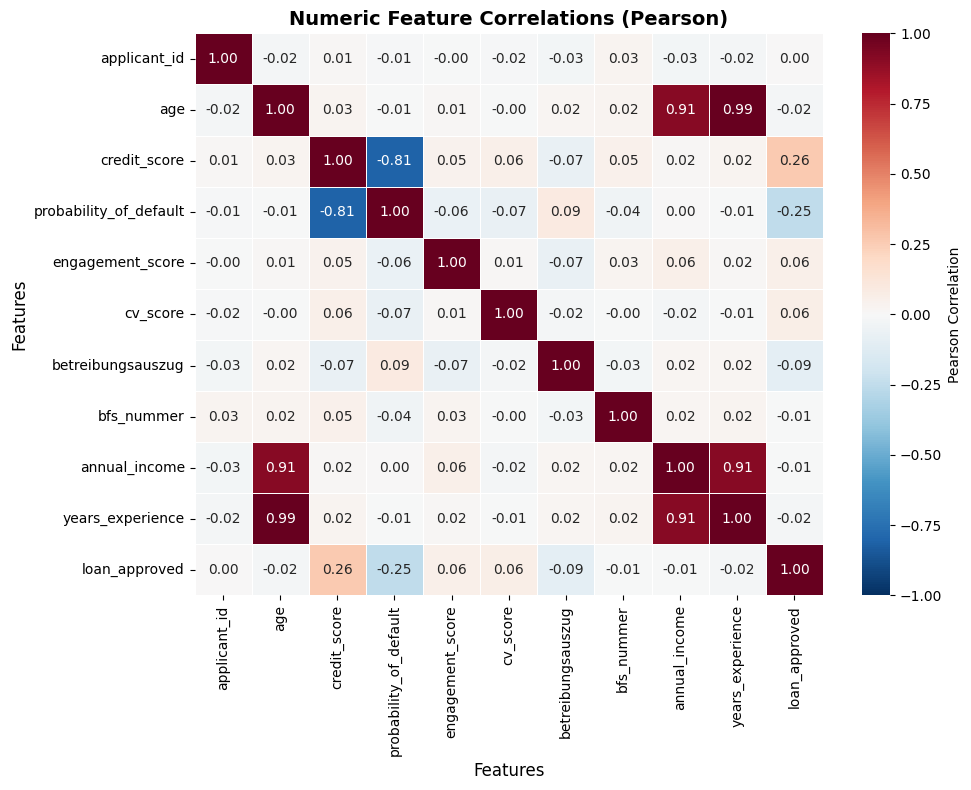

In [14]:
# Pearson correlation matrix across numeric features
ax = plot_feature_correlation_matrix(
    df,
    # Auto-select numeric features
    annotate=True,
    title='Numeric Feature Correlations (Pearson)'
)


In [15]:
# Detailed proxy correlation analysis
zip_race_correlation = compute_proxy_correlations(df, 'zip_code', 'race')

print("Detailed Proxy Analysis: ZIP Code → Race")
print("=" * 50)
print(f"\nPrimary Correlation ({zip_race_correlation['primary_correlation_type']}): "
      f"{zip_race_correlation['primary_correlation']:.3f}")
print(f"Risk Level: {zip_race_correlation['risk_level']}")
print(f"Is Known Proxy Pattern: {zip_race_correlation['is_known_pattern']}")
print(f"\nAll Correlation Measures:")
for measure, value in zip_race_correlation['all_correlations'].items():
    print(f"  {measure}: {value:.4f}")

Detailed Proxy Analysis: ZIP Code → Race

Primary Correlation (Cramér's V): 0.907
Risk Level: critical
Is Known Proxy Pattern: True

All Correlation Measures:
  pearson: 0.1052
  pvalue: 0.0000
  spearman: 0.1125
  cramers_v: 0.9068
  chi2_pvalue: 0.0000
  mutual_information: 0.3148


---

## 6. Unified BiasDetector

The `BiasDetector` class combines all four detection capabilities into a single, comprehensive audit workflow.

> **⚠️ LIMITATION — Risk Score is a Heuristic & Silent Exception Swallowing**
>
> **Gap:** The `BiasDetector.overall_risk_score` is computed using manually chosen, hard-coded weights — it is **not** a calibrated statistical measure. Different weighting schemes can yield significantly different conclusions. Additionally, `BiasDetector` silently catches and swallows exceptions in individual detection modules, which means a module failure may go unnoticed and produce an incomplete audit.
>
> **Mitigation:** Do not use the overall risk score as a compliance metric. Instead, examine individual findings from each module separately. Always check `len(report.findings)` against expected counts. For production use, wrap `BiasDetector` calls with your own exception handling and logging.

> **⚠️ LIMITATION — Geographic Data is US-Only**
>
> **Gap:** HOLC redlining data covers approximately 40 US cities and ~100 ZIP codes. The CDC Social Vulnerability Index is US-only. **No European, Swiss, or APAC geographic discrimination data** is included in the library.
>
> **Mitigation:** For non-US jurisdictions, build custom geographic risk datasets. Sources: Eurostat NUTS regions, Swiss BFS Gemeindetypologie, UK Index of Multiple Deprivation. Use `assess_geographic_feature_risk()` with your own reference data.

In [16]:
# Create a BiasDetector
detector = BiasDetector(
    df,
    protected_attributes=['race', 'gender', 'age'],
    outcome_column='loan_approved',
    benchmarks=benchmarks
)

# Run full audit
report = detector.full_audit(
    include_historical=True,
    include_representation=True,
    include_disparities=True,
    include_proxies=True,
    include_intersectional=True
)

# Print summary
print(report.summary())

BIAS DETECTION AUDIT REPORT
Timestamp: 2026-02-11T15:42:16.084462
Dataset: 2000 rows, 19 columns
Protected Attributes: race, gender, age

Overall Risk Score: 100.0%

----------------------------------------------------------------------
SUMMARY OF FINDINGS
----------------------------------------------------------------------
Historical Pattern Issues: 12
Representation Bias Issues: 3
Statistical Disparities: 20
Proxy Variables Identified: 7

----------------------------------------------------------------------
CRITICAL ISSUES (Require Immediate Attention)
----------------------------------------------------------------------
1. [Historical Pattern] Feature 'country_of_origin' encodes historical discrimination pattern: Migration Background Discrimination
2. [Historical Pattern] Feature 'engagement_score' encodes historical discrimination pattern: Emotion Recognition — PROHIBITED in workplace/education (Art. 5(1)(f))
3. [Historical Pattern] Feature 'permit_type' encodes historical disc

In [17]:
# Access individual findings — show ALL results (no truncation)
print("\nDETAILED FINDINGS")
print("=" * 80)

# ── 1. Historical Pattern Findings ───────────────────────────────────────────
print(f"\n1. Historical Pattern Findings: {len(report.historical_findings)}")
print("-" * 60)
for i, h in enumerate(report.historical_findings, 1):
    risk_icon = {"critical": "🚨", "high": "🔴", "medium": "🟡", "low": "🟢", "none": "⚪"}.get(h.risk_level.value, "❓")
    print(f"   {i:2d}. {risk_icon} {h.feature:30s} {h.risk_level.value:8s}  │ {h.pattern_type}")

# ── 2. Representation Findings ───────────────────────────────────────────────
print(f"\n2. Representation Findings: {len(report.representation_findings)}")
print("-" * 60)
for i, r in enumerate(report.representation_findings, 1):
    sev_icon = {"critical": "🚨", "high": "🔴", "moderate": "🟡", "adequate": "🟢"}.get(r.severity.value, "❓")
    ug_str = ""
    if hasattr(r, 'underrepresented_groups') and r.underrepresented_groups:
        ug_str = f"  │ underrep: {', '.join(str(g) for g in r.underrepresented_groups)}"
    print(f"   {i:2d}. {sev_icon} {r.attribute:30s} {r.severity.value:8s}{ug_str}")

# ── 3. Statistical Disparity Findings ────────────────────────────────────────
print(f"\n3. Statistical Disparity Findings: {len(report.disparity_findings)}")
print("-" * 60)
print(f"   {'#':>4s}  {'Feature':30s} {'By':15s} {'Effect':>8s}  {'Size':10s}  {'Sig.':>8s}")
print(f"   {'─'*4}  {'─'*30} {'─'*15} {'─'*8}  {'─'*10}  {'─'*8}")
for i, d in enumerate(report.disparity_findings, 1):
    eff_icon = {"large": "🔴", "medium": "🟡", "small": "🟢", "negligible": "⚪"}.get(d.effect_interpretation.value, "❓")
    sig_str = f"p={d.p_value:.4f}" if hasattr(d, 'p_value') and d.p_value is not None else "n/a"
    print(f"   {i:4d}. {d.feature:30s} {d.protected_attribute:15s} {d.effect_size:8.3f}  {eff_icon} {d.effect_interpretation.value:8s}  {sig_str}")

# ── 4. Proxy Variable Findings ───────────────────────────────────────────────
print(f"\n4. Proxy Variable Findings: {len(report.proxy_findings)}")
print("-" * 60)
for i, p in enumerate(report.proxy_findings, 1):
    risk_icon = {"critical": "🚨", "high": "🔴", "medium": "🟡", "low": "🟢", "negligible": "⚪"}.get(p.risk_level.value, "❓")
    print(f"   {i:2d}. {risk_icon} {p.feature:30s} → {p.protected_attribute:10s}  r={p.correlation:.3f}  ({p.risk_level.value})")

print("\n" + "=" * 80)
print(f"Total findings: {len(report.historical_findings) + len(report.representation_findings) + len(report.disparity_findings) + len(report.proxy_findings)}")


DETAILED FINDINGS

1. Historical Pattern Findings: 12
------------------------------------------------------------
    1. 🚨 country_of_origin              critical  │ Migration Background Discrimination
    2. 🚨 engagement_score               critical  │ Emotion Recognition — PROHIBITED in workplace/education (Art. 5(1)(f))
    3. 🚨 permit_type                    critical  │ Swiss Residence Permit Discrimination
    4. 🔴 probability_of_default         high      │ High-Risk: Creditworthiness Assessment (Annex III, area 5(b))
    5. 🔴 postcode_score                 high      │ Geographic Redlining
    6. 🔴 cv_score                       high      │ High-Risk: Employment & Recruitment (Annex III, area 4)
    7. 🔴 bfs_nummer                     high      │ Swiss Municipality-Level Discrimination
    8. 🔴 zip_code                       high      │ Geographic Redlining
    9. 🔴 betreibungsauszug              high      │ Swiss Debt Register Discrimination
   10. 🟡 language_score             

In [18]:
# Get high-risk features
# ──────────────────────────────────────────────────────────────────────────────
# report.get_high_risk_features() aggregates features flagged as CRITICAL or
# HIGH across two detection modules:
#
#   1. Historical Pattern Detection  – features whose names match known
#      discriminatory patterns (e.g. redlining ZIP codes, permit types).
#   2. Proxy Variable Identification – features with strong statistical
#      correlation (Cramér's V ≥ 0.5) to a protected attribute.
#
# It does NOT include Statistical Disparity or Representation findings.
# The result is a sorted list of unique column names that warrant immediate
# review or removal before model training.
# ──────────────────────────────────────────────────────────────────────────────

high_risk_features = report.get_high_risk_features()

print(f"High-Risk Features Requiring Attention: {len(high_risk_features)}")
print("=" * 60)
if high_risk_features:
    for feature in high_risk_features:
        # Show which module(s) flagged this feature
        sources = []
        for h in report.historical_findings:
            if h.feature == feature and h.risk_level.value in ("critical", "high"):
                sources.append(f"Historical ({h.risk_level.value})")
                break
        for p in report.proxy_findings:
            if p.feature == feature and p.risk_level.value in ("critical", "high"):
                sources.append(f"Proxy ({p.risk_level.value})")
                break
        print(f"  ⚠️  {feature:30s} ← {', '.join(sources)}")
else:
    print("  (none — no features reached CRITICAL or HIGH risk level)")

High-Risk Features Requiring Attention: 10
  ⚠️  betreibungsauszug              ← Historical (high)
  ⚠️  bfs_nummer                     ← Historical (high)
  ⚠️  country_of_origin              ← Historical (critical), Proxy (critical)
  ⚠️  cv_score                       ← Historical (high)
  ⚠️  engagement_score               ← Historical (critical)
  ⚠️  permit_type                    ← Historical (critical)
  ⚠️  postcode_score                 ← Historical (high)
  ⚠️  probability_of_default         ← Historical (high)
  ⚠️  years_experience               ← Proxy (critical)
  ⚠️  zip_code                       ← Historical (high), Proxy (critical)


In [19]:
# Export report to JSON
import json

report_json = report.to_json(indent=2)
print("Report exported to JSON format")
print(f"Total size: {len(report_json)} characters")

# Preview first 1000 characters
print("\nPreview:")
print(report_json[:1000] + "...")

Report exported to JSON format
Total size: 98148 characters

Preview:
{
  "timestamp": "2026-02-11T15:42:16.084462",
  "dataset_info": {
    "n_rows": 2000,
    "n_columns": 19,
    "columns": [
      "applicant_id",
      "gender",
      "race",
      "age",
      "zip_code",
      "school_name",
      "credit_score",
      "country_of_origin",
      "postcode_score",
      "language_score",
      "probability_of_default",
      "engagement_score",
      "cv_score",
      "permit_type",
      "betreibungsauszug",
      "bfs_nummer",
      "annual_income",
      "years_experience",
      "loan_approved"
    ],
    "protected_attributes": [
      "race",
      "gender",
      "age"
    ],
    "outcome_column": "loan_approved"
  },
  "protected_attributes": [
    "race",
    "gender",
    "age"
  ],
  "historical_findings": [
    {
      "feature": "country_of_origin",
      "risk_level": "critical",
      "pattern_type": "Migration Background Discrimination",
      "description": "Colum

---

## 7. Real-World Use Case: Loan Application Audit

Let's simulate a complete audit workflow for a loan application system.

In [20]:
def run_loan_audit(df, protected_attrs, benchmarks):
    """
    Complete bias audit workflow for a loan application system.
    """
    print("\n" + "=" * 80)
    print("           LOAN APPLICATION BIAS AUDIT REPORT")
    print("=" * 80)
    
    # Initialize detector
    detector = BiasDetector(
        df,
        protected_attributes=protected_attrs,
        outcome_column='loan_approved',
        benchmarks=benchmarks
    )
    
    # Run full audit
    report = detector.full_audit()
    
    # 1. Executive Summary
    print("\n" + "-" * 80)
    print("EXECUTIVE SUMMARY")
    print("-" * 80)
    print(f"\nOverall Risk Score: {report.overall_risk_score:.1%}")
    risk_level = "LOW" if report.overall_risk_score < 0.2 else "MEDIUM" if report.overall_risk_score < 0.5 else "HIGH"
    print(f"Risk Level: {risk_level}")
    print(f"\nFindings Summary:")
    print(f"  - Historical patterns identified: {len(report.historical_findings)}")
    print(f"  - Representation issues: {len(report.representation_findings)}")
    print(f"  - Statistical disparities: {len(report.disparity_findings)}")
    print(f"  - Proxy variables detected: {len(report.proxy_findings)}")
    print(f"  - Critical issues: {report.get_critical_count()}")
    
    # 2. Critical Issues
    if report.critical_issues:
        print("\n" + "-" * 80)
        print("CRITICAL ISSUES (Immediate Action Required)")
        print("-" * 80)
        for i, issue in enumerate(report.critical_issues, 1):
            print(f"\n{i}. [{issue['type']}]")
            print(f"   {issue['description']}")
            if 'recommendations' in issue and issue['recommendations']:
                print(f"   Action: {issue['recommendations'][0]}")
    
    # 3. Approval Rate Analysis
    print("\n" + "-" * 80)
    print("APPROVAL RATE ANALYSIS")
    print("-" * 80)
    
    overall_rate = df['loan_approved'].mean()
    print(f"\nOverall Approval Rate: {overall_rate:.1%}")
    
    for attr in protected_attrs:
        if attr in df.columns:
            print(f"\nApproval Rate by {attr.title()}:")
            rates = df.groupby(attr)['loan_approved'].agg(['mean', 'count'])
            max_rate = rates['mean'].max()
            for group, row in rates.iterrows():
                disparity = (max_rate - row['mean']) / max_rate if max_rate > 0 else 0
                flag = " ⚠️" if disparity > 0.1 else ""
                print(f"  {group}: {row['mean']:.1%} (n={int(row['count'])}){flag}")
    
    # 4. Recommendations
    print("\n" + "-" * 80)
    print("RECOMMENDATIONS")
    print("-" * 80)
    for i, rec in enumerate(report.recommendations, 1):
        print(f"\n{i}. {rec}")
    
    # 5. Compliance Checklist
    print("\n" + "-" * 80)
    print("COMPLIANCE CHECKLIST")
    print("-" * 80)
    
    checks = [
        ("Representation adequate for all groups", 
         all(r.severity.value not in ['critical', 'high'] for r in report.representation_findings)),
        ("No high-risk historical patterns",
         not any(h.risk_level.value == 'critical' for h in report.historical_findings)),
        ("No large effect disparities",
         not any(d.effect_interpretation.value == 'large' for d in report.disparity_findings)),
        ("No critical proxy variables",
         not any(p.risk_level.value == 'critical' for p in report.proxy_findings)),
    ]
    
    for check, passed in checks:
        status = "✓" if passed else "✗"
        print(f"  [{status}] {check}")
    
    print("\n" + "=" * 80)
    print(f"Audit completed at: {report.timestamp}")
    print("=" * 80)
    
    return report

# Run the audit
audit_report = run_loan_audit(df, ['race', 'gender'], benchmarks)


           LOAN APPLICATION BIAS AUDIT REPORT

--------------------------------------------------------------------------------
EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

Overall Risk Score: 95.6%
Risk Level: HIGH

Findings Summary:
  - Historical patterns identified: 12
  - Representation issues: 2
  - Statistical disparities: 19
  - Proxy variables detected: 6
  - Critical issues: 10

--------------------------------------------------------------------------------
CRITICAL ISSUES (Immediate Action Required)
--------------------------------------------------------------------------------

1. [Historical Pattern]
   Feature 'country_of_origin' encodes historical discrimination pattern: Migration Background Discrimination
   Action: Never use nationality or dual citizenship as fraud indicators

2. [Historical Pattern]
   Feature 'engagement_score' encodes historical discrimination pattern: Emotion Recognition — PROHIBITED in work

### 📊 SVG Visual Dashboard

Generate an interactive SVG dashboard from the audit report using the `vfairness.rendering` module:

In [21]:
# Generate SVG dashboard from the audit report
from IPython.display import SVG, display
from vfairness.rendering import bias_audit_to_svg

svg_output = bias_audit_to_svg(audit_report)
print(f"SVG dashboard size: {len(svg_output):,} bytes")
display(SVG(data=svg_output))

AttributeError: 'BiasAuditReport' object has no attribute 'to_svg'

---
## FairnessExplainer — Educational Explanations

The `FairnessExplainer` facade provides educational, context-aware explanations for any result object in the vfairness library. Each major class also exposes a convenience `get_explanation()` method.

In [ ]:
# FairnessExplainer — unified explanation facade
from vfairness.explainer import FairnessExplainer

# Option 1: Convenience method on the class
explanation = detector.get_explanation(report)
print(explanation)
print()

# Option 2: Via the unified facade (works with any result type)
explanation2 = FairnessExplainer.explain(report)
print(f"Title   : {explanation2.title}")
print(f"Severity: {explanation2.severity}")
print(f"Summary : {explanation2.summary}")
print()
for expl in explanation2.explanations:
    print(f"  [{expl.severity.upper():8s}] {expl.metric_name}: {expl.value}")

In [ ]:
# ── Validation · FairnessExplainer ───────────────────────────────────────────────────────────
from vfairness.explainer import FairnessExplainer, ExplanationReport

explanation = detector.get_explanation(report)

assert isinstance(explanation, ExplanationReport), \
    f"Expected ExplanationReport, got {type(explanation).__name__}"
assert explanation.title == 'Bias Audit Explanation', \
    f"Unexpected title: {explanation.title}"
assert len(explanation.explanations) > 0, \
    "ExplanationReport should contain at least one explanation"
assert explanation.severity in ('info', 'low', 'medium', 'high', 'critical'), \
    f"Invalid severity: {explanation.severity}"

# Facade should produce identical result
explanation2 = FairnessExplainer.explain(report)
assert explanation2.title == explanation.title
assert FairnessExplainer.can_explain(report) is True

print(f"✓ FairnessExplainer | {len(explanation.explanations)} explanation(s) | "
      f"severity={explanation.severity} | facade ✓")

---

## Summary

The `vfairness.bias_detection` module provides comprehensive capabilities for detecting bias in raw data:

### Building Blocks

| Block | Purpose | Key Features |
|-------|---------|-------------|
| **A. Historical Pattern Detection** | Identify features linked to historical discrimination | 43 patterns across US, EU, EU AI Act & CH; risk scoring; academic citations |
| **B. Representation Bias Detection** | Detect under/overrepresentation | Chi-squared tests, benchmark comparison, intersectional analysis |
| **C. Statistical Disparity Analysis** | Rigorous hypothesis testing | T-tests, ANOVA, effect sizes, confidence intervals, multiple comparison correction |
| **D. Proxy Variable Identification** | Find features correlated with protected attributes | Multiple correlation measures, known patterns, proxy chains |
| **E. Geographic Discrimination Data** | Integration with official databases | HOLC redlining maps, CDC Social Vulnerability Index, ZIP code risk assessment |

### EU AI Act Compliance Detection

The module includes **11 EU AI Act (Regulation 2024/1689) patterns** that automatically flag features falling under:

- **4 Prohibited practices** (Art. 5): Social scoring, emotion recognition in workplace/education, biometric categorisation by sensitive attributes, manipulative/subliminal AI
- **7 High-risk use cases** (Annex III): Employment & recruitment, creditworthiness, education, essential services & insurance, law enforcement, migration & border control, justice & democratic processes

### Key Classes

- `BiasDetector`: Unified interface for all detection capabilities
- `BiasAuditReport`: Comprehensive audit report with findings and recommendations

### Geographic Data Integration

New capabilities for geographic discrimination analysis:
- **HOLC Redlining Maps**: Access historical data from 40+ US cities via `get_available_holc_cities()`, `lookup_holc_grade_by_zip()`
- **Geographic Risk Assessment**: Analyze ZIP code features for disparate impact via `assess_geographic_feature_risk()`
- **CDC Social Vulnerability Index**: Contemporary vulnerability data via `SVI_THEMES`, `get_svi_data_url()`

### ⚠️ Known Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| **Detection only** — no mitigation algorithms | Cannot fix detected bias | Use AIF360, Fairlearn for mitigation |
| **Keyword-based matching** — not NLP/semantic | Misses renamed/encoded columns | Manually review all columns |
| **Benchmarks not auto-generated** — US Census defaults only | Misleading for EU/CH contexts | Provide custom benchmarks from Eurostat, BFS |
| **Correlation ≠ causation** — proxy chains statistically invalid | May overstate indirect bias | Use DoWhy/CausalML for causal claims |
| **Small groups silently dropped** — `min_group_size=30` | Minorities & intersections invisible | Lower threshold; verify group counts |
| **Geographic data US-only** — ~40 cities, ~100 ZIPs | No EU/CH geographic analysis | Build custom geographic risk datasets |
| **Risk score is heuristic** — manually weighted | Not a calibrated measure | Examine individual module findings separately |
| **Silent exception swallowing** — BiasDetector catches errors | Incomplete audits may go unnoticed | Check finding counts; add your own logging |

> ⚠️ **Limitation callouts** are marked with the ⚠️ symbol throughout this notebook at each relevant section. See the [HTML documentation](docs/site/) for the full limitation reference with detailed mitigation strategies.

### Academic References

All historical patterns are grounded in peer-reviewed research:
- Barocas & Selbst (2016) - Big Data's Disparate Impact
- Obermeyer et al. (2019) - Healthcare algorithm bias
- Bertrand & Mullainathan (2004) - Name discrimination
- Rothstein (2017) - The Color of Law (redlining)
- Eubanks (2018) - Automating Inequality
- Buolamwini & Gebru (2018) - Gender Shades (biometric bias)
- Barrett et al. (2019) - Emotion recognition scientific validity

### Best Practices

1. **Run full audits** before model training to catch bias at the source
2. **Use appropriate benchmarks** for representation analysis
3. **Consider intersectionality** - bias often occurs at intersections
4. **Assess geographic features** for historical discrimination patterns
5. **Check EU AI Act compliance** - identify prohibited and high-risk features early
6. **Document findings** and track remediation efforts
7. **Integrate into CI/CD** for continuous monitoring